# Forecasting and Baselines

Reproduces the paper's forecasting results end to end: the seed-42 XGBoost
model (Table II), the 5-seed baseline comparison (Table IV), the block
bootstrap significance test (Section VI-B), and the feature ablation
(Section VI-C). Every stochastic step uses the same fixed seeds as
`evloadshaping.cli` (`evloadshaping.config.SEEDS`), so the numbers below
should match the paper exactly, not just approximately.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.config import SEEDS
from evloadshaping.data import load_raw_data
from evloadshaping.features import build_features, split_data
from evloadshaping.models import (
    compute_baselines,
    evaluate_model,
    evaluate_xgboost_seeds,
    persistence_predictions,
    run_feature_ablation,
    train_model,
)
from evloadshaping.plotting import plot_forecast_zoom, plot_forecasts
from evloadshaping.significance import block_bootstrap_mae_diff

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')
print(f'Seeds used for every multi-seed table below: {SEEDS}')


Seeds used for every multi-seed table below: (42, 43, 44, 45, 46)


In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)
print(f'Train: {len(x_train):,} rows | Test: {len(x_test):,} rows')


Train: 46,144 rows | Test: 11,537 rows


## Single-run XGBoost (Table II)

The paper's headline metrics use a single fixed seed (42, `train_model`'s
default) rather than the 5-seed mean, so this cell alone reproduces Table II
exactly.


In [3]:
model_pv = train_model(x_train, y_pv_train)
model_ev = train_model(x_train, y_ev_train)

pv_predictions = model_pv.predict(x_test)
ev_predictions = model_ev.predict(x_test)

pv_metrics = evaluate_model(y_pv_test, pv_predictions)
ev_metrics = evaluate_model(y_ev_test, ev_predictions)

pd.DataFrame({'PV forecast': pv_metrics, 'EV demand forecast': ev_metrics}).round(2)


,PV forecast,EV demand forecast
mae,453.87,64.86
rmse,963.92,296.19


## Baseline and 5-seed comparison (Table IV)

XGBoost's own subsampling (`subsample=0.9`, `colsample_bytree=0.9`) makes
`random_state` a real variance source, so the paper reports XGBoost as a
5-seed mean +/- std here, not the single seed-42 run above. Persistence and
ridge regression are deterministic, so they need no seed sweep.


In [4]:
baselines = compute_baselines(x_test, y_pv_test, y_ev_test, x_train, y_pv_train, y_ev_train)
xgb_pv_seeds = evaluate_xgboost_seeds(x_train, y_pv_train, x_test, y_pv_test)
xgb_ev_seeds = evaluate_xgboost_seeds(x_train, y_ev_train, x_test, y_ev_test)

comparison = pd.DataFrame([
    {'model': 'persistence', 'target': 'pv', **baselines['persistence']['pv']},
    {'model': 'ridge_regression', 'target': 'pv', **baselines['ridge_regression']['pv']},
    {'model': 'xgboost (5-seed mean)', 'target': 'pv', **xgb_pv_seeds},
    {'model': 'persistence', 'target': 'ev', **baselines['persistence']['ev']},
    {'model': 'ridge_regression', 'target': 'ev', **baselines['ridge_regression']['ev']},
    {'model': 'xgboost (5-seed mean)', 'target': 'ev', **xgb_ev_seeds},
])
comparison.round(2)


,model,target,mae,rmse,mae_std,rmse_std
0,persistence,pv,465.35,1024.03,NaN,NaN
1,ridge_regression,pv,503.99,977.85,NaN,NaN
2,xgboost (5-seed mean),pv,451.01,960.50,2.58,3.43
3,persistence,ev,52.29,273.24,NaN,NaN
4,ridge_regression,ev,64.41,265.35,NaN,NaN
5,xgboost (5-seed mean),ev,65.40,300.96,0.76,7.69


## Is XGBoost's edge over persistence statistically robust? (Section VI-B)

An i.i.d. bootstrap overstates confidence on autocorrelated 15-minute
telemetry, so this uses a moving block bootstrap (24h blocks = 96 intervals,
10,000 resamples) on the *same* seed-42 predictions from Table II. The
statistic is `MAE(XGBoost) - MAE(persistence)`: negative means XGBoost
helps, positive means persistence is better; "significant" means the 95% CI
excludes zero.


In [5]:
persistence_pv, persistence_ev = persistence_predictions(x_test)

bootstrap_pv = block_bootstrap_mae_diff(y_pv_test.to_numpy(), pv_predictions, persistence_pv)
bootstrap_ev = block_bootstrap_mae_diff(y_ev_test.to_numpy(), ev_predictions, persistence_ev)

pd.DataFrame([
    {'target': 'pv', **bootstrap_pv},
    {'target': 'ev', **bootstrap_ev},
]).round(2)


,target,point_estimate_w,ci_lower_w,ci_upper_w,confidence,block_size,n_resamples,significant
0,pv,-11.49,-36.98,23.29,0.95,96,10000,False
1,ev,12.56,8.12,18.41,0.95,96,10000,True


In [6]:
print(
    f"PV: XGBoost {'beats' if bootstrap_pv['point_estimate_w'] < 0 else 'trails'} persistence by "
    f"{abs(bootstrap_pv['point_estimate_w']):.2f} W, but the 95% CI "
    f"[{bootstrap_pv['ci_lower_w']:.1f}, {bootstrap_pv['ci_upper_w']:.1f}] "
    f"{'excludes' if bootstrap_pv['significant'] else 'includes'} zero -> "
    f"{'robust' if bootstrap_pv['significant'] else 'NOT statistically robust'}."
)
print(
    f"EV: XGBoost trails persistence by {bootstrap_ev['point_estimate_w']:.2f} W, "
    f"95% CI [{bootstrap_ev['ci_lower_w']:.1f}, {bootstrap_ev['ci_upper_w']:.1f}] "
    f"{'excludes' if bootstrap_ev['significant'] else 'includes'} zero -> "
    f"persistence's EV advantage is {'robust' if bootstrap_ev['significant'] else 'NOT robust'}."
)


PV: XGBoost beats persistence by 11.49 W, but the 95% CI [-37.0, 23.3] includes zero -> NOT statistically robust.
EV: XGBoost trails persistence by 12.56 W, 95% CI [8.1, 18.4] excludes zero -> persistence's EV advantage is robust.


## Feature ablation (lag/rolling features vs. current-timestep only)


In [7]:
ablation = run_feature_ablation(x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test)

ablation_table = pd.DataFrame([
    {'feature_set': 'base_only', 'target': 'pv', **ablation['base_features_only']['pv']},
    {'feature_set': 'full', 'target': 'pv', **pv_metrics},
    {'feature_set': 'base_only', 'target': 'ev', **ablation['base_features_only']['ev']},
    {'feature_set': 'full', 'target': 'ev', **ev_metrics},
])
ablation_table.round(2)


,feature_set,target,mae,rmse
0,base_only,pv,544.05,1142.20
1,full,pv,453.87,963.92
2,base_only,ev,77.88,333.91
3,full,ev,64.86,296.19


## Feature importance and forecast plots


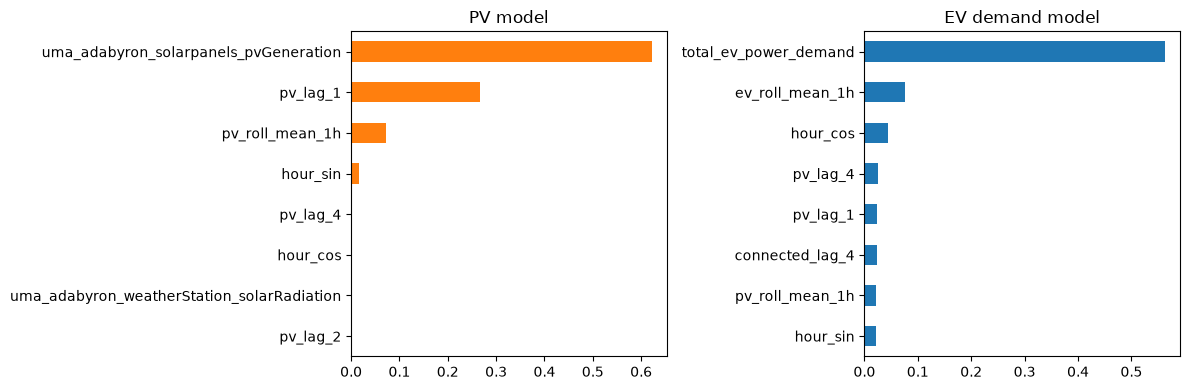

In [8]:
def top_importances(model, feature_names, n=8):
    return (
        pd.Series(model.feature_importances_, index=feature_names)
        .sort_values(ascending=False)
        .head(n)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
top_importances(model_pv, x_train.columns).plot.barh(ax=axes[0], color='tab:orange')
axes[0].invert_yaxis()
axes[0].set_title('PV model')

top_importances(model_ev, x_train.columns).plot.barh(ax=axes[1], color='tab:blue')
axes[1].invert_yaxis()
axes[1].set_title('EV demand model')
fig.tight_layout()
plt.show()


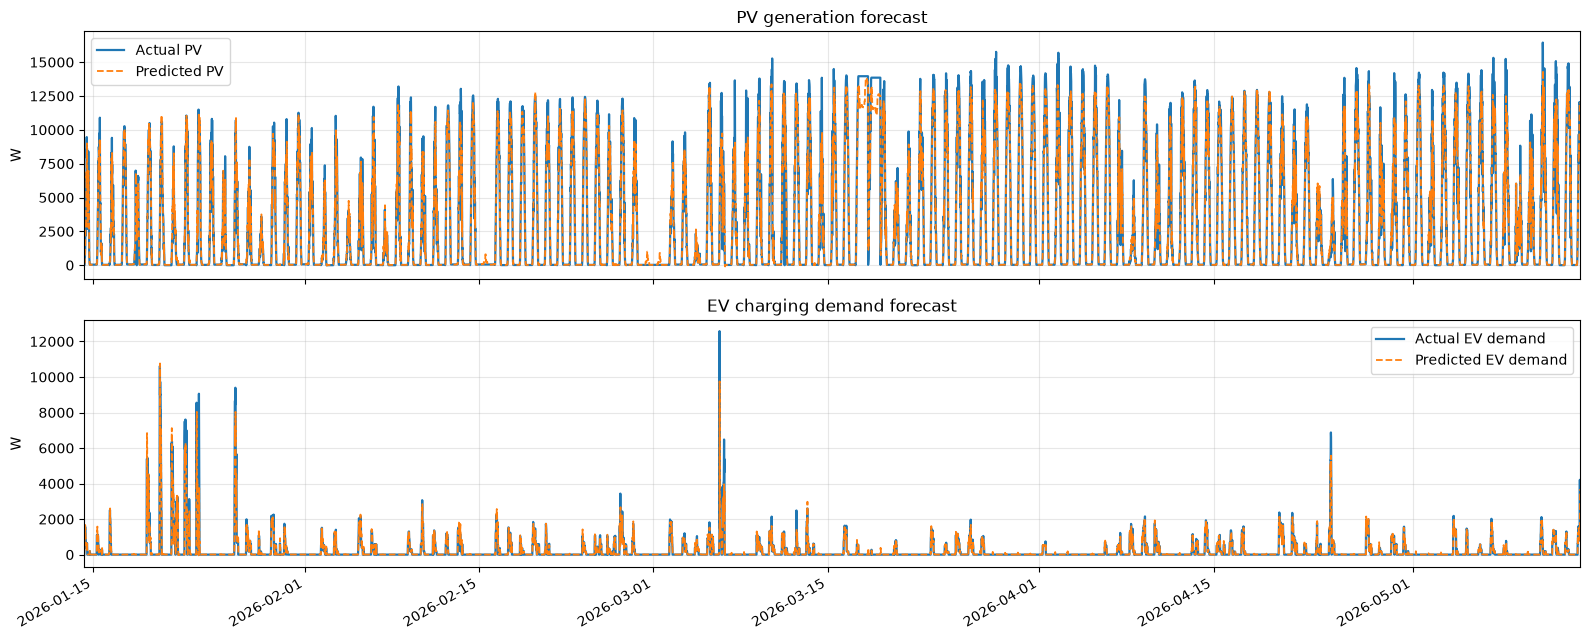

In [9]:
# Full test horizon (coverage sanity check; each day is a sliver at this scale)
fig = plot_forecasts(
    test_index=x_test.index,
    actual_pv=y_pv_test,
    predicted_pv=pv_predictions,
    actual_ev=y_ev_test,
    predicted_ev=ev_predictions,
)
plt.show()


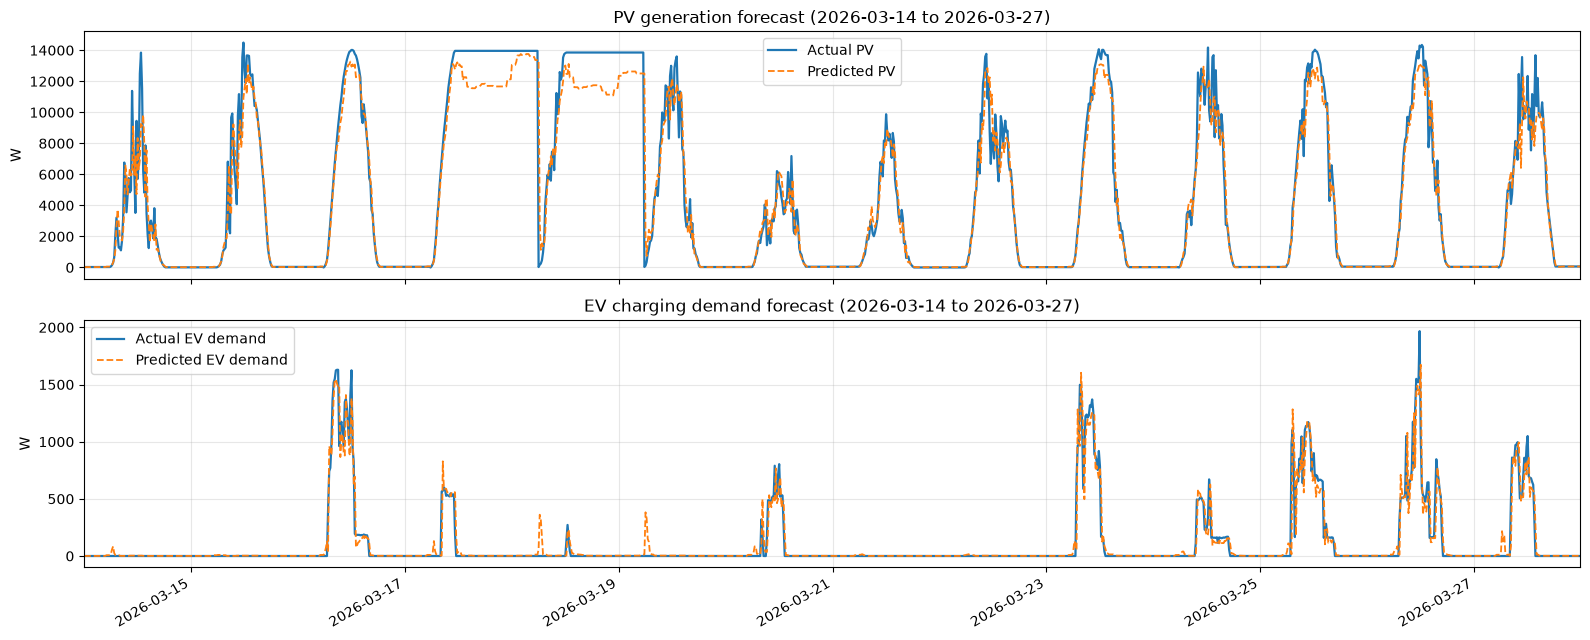

In [10]:
# Zoomed, representative window -- this is the paper's Fig. 1
fig = plot_forecast_zoom(
    test_index=x_test.index,
    actual_pv=y_pv_test,
    predicted_pv=pv_predictions,
    actual_ev=y_ev_test,
    predicted_ev=ev_predictions,
)
plt.show()
